Line 1: # Importing essential libraries</br>
This is a comment explaining what the cell does</br>
Line 2: import pandas as pd</br>
Imports pandas library with alias 'pd' for data manipulation</br>
Line 3: import numpy as np</br>
Imports numpy library with alias 'np' for mathematical operations</br>


In [89]:
# Importing essential libraries
import pandas as pd
import numpy as np

In [ ]:
# Loading the dataset
df = pd.read_csv('ipl_data_file.csv')

# Loads the CSV file into a DataFrame called 'df'

## **Exploring the dataset**

In [ ]:
df.columns

# df is your DataFrame containing the IPL data
# .columns is a pandas attribute that returns the column labels

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [ ]:
df.shape
# df is your DataFrame containing the IPL data</br>
# .shape is a pandas attribute that returns a tuple with (rows, columns)</br>

(76014, 15)

In [ ]:
df.dtypes

# df is your DataFrame containing the IPL data
# .dtypes is a pandas attribute that returns the data type of each column

date              datetime64[ns]
bat_team                  object
bowl_team                 object
runs                       int64
wickets                    int64
overs                    float64
runs_last_5                int64
wickets_last_5             int64
total                      int64
dtype: object

In [ ]:
df.head()
# df is our dataframe where we have stored our data
# .head displays the firts five records in our file 

,date,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
32,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222
33,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222
34,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,59,1,222
35,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,59,1,222
36,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,58,1,222


## **Data Cleaning**
Points covered under this section:<br/>
*• Removing unwanted columns*<br/>
*• Keeping only consistent teams*<br/>
*• Removing the first 5 overs data in every match*<br/>
*• Converting the column 'date' from string into datetime object*<br/>

In [ ]:
df.columns
# It gives all the columns in our dataset 


Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [ ]:
# Removing unwanted columns
columns_to_remove = ['mid', 'venue', 'batsman', 'bowler', 'striker', 'non-striker']

print('Before removing unwanted columns: {}'.format(df.shape))
df.drop(labels=columns_to_remove, axis=1, inplace=True)
print('After removing unwanted columns: {}'.format(df.shape))


# Creates a list of column names that will be removed from the dataset
# Prints the dataset shape before removing columns
# Removes the specified columns from the dataset
# Prints the dataset shape after removing columns


Before removing unwanted columns: (76014, 15)
After removing unwanted columns: (76014, 9)


In [ ]:
df.columns
# It gives all the columns in our dataset after removing unwanted columns.

Index(['date', 'bat_team', 'bowl_team', 'runs', 'wickets', 'overs',
       'runs_last_5', 'wickets_last_5', 'total'],
      dtype='object')

In [ ]:
df.head()
# It gives the first 5 rows of our dataset after removing unwanted columns.


,date,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
0,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,1,0,222
1,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,1,0,222
2,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,2,0,222
3,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,2,0,222
4,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,2,0,222


In [ ]:
df.index
# It gives the index of our dataset.

RangeIndex(start=0, stop=76014, step=1)

In [ ]:
df['bat_team'].unique()

# It gives the unique values of the column 'bat_team'.

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Deccan Chargers', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Daredevils',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant'], dtype=object)

In [ ]:
consistent_teams = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
                    'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
                    'Delhi Daredevils', 'Sunrisers Hyderabad']

# Replace all the team names with the consistent names
#This cell defines which teams to keep in the analysis.
# These are the teams that have been consistent throughout 
#the IPL seasons and have sufficient data for reliable predictions.



In [ ]:
# Keeping only consistent teams
print('Before removing inconsistent teams: {}'.format(df.shape))
df = df[(df['bat_team'].isin(consistent_teams)) & (df['bowl_team'].isin(consistent_teams))]
print('After removing inconsistent teams: {}'.format(df.shape))

# This cell filters the dataset to only include rows where the 'bat_team' and 'bowl_team' columns match the consistent_teams list.
# It prints the shape of the dataset before and after filtering to show how many rows were removed.
# The & operator is used to apply both conditions (team in bat_team and team in bowl_team) to filter the dataset.
# The .isin() method checks if the values in the 'bat_team' and 'bowl_team' columns are present in the consistent_teams list.
# The result is a new DataFrame df that only contains rows where the 'bat_team' and 'bowl_team' values match the consistent_teams list.
# The shape of the dataset is printed before and after filtering to show how many rows were removed.
# 

Before removing inconsistent teams: (76014, 9)
After removing inconsistent teams: (53811, 9)


In [ ]:
df['bat_team'].unique()

# This cell displays the unique values in the 'bat_team' column of the DataFrame df.
# The .unique() method returns an array of unique values in the specified column.
# The output shows the different team names that appear in the 'bat_team' column.
# This helps identify the teams that are present in the dataset.

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
       'Delhi Daredevils', 'Sunrisers Hyderabad'], dtype=object)

In [ ]:
# Removing the first 5 overs data in every match
print('Before removing first 5 overs data: {}'.format(df.shape))
df = df[df['overs']>=5.0]
print('After removing first 5 overs data: {}'.format(df.shape))

# This cell filters the dataset to only include rows where the 'overs' column is greater than or equal to 5.0.
# It prints the shape of the dataset before and after filtering to show how many rows were removed.
# The >= operator is used to check if the value in the 'overs' column is greater than or equal to 5.0.
# The result is a new DataFrame df that only contains rows where the 'overs' value is greater than or equal to 5.0.
# The shape of the dataset is printed before and after filtering to show how many rows were removed.


Before removing first 5 overs data: (53811, 9)
After removing first 5 overs data: (40108, 9)


In [ ]:
# Converting the column 'date' from string into datetime object
from datetime import datetime
print("Before converting 'date' column from string to datetime object: {}".format(type(df.iloc[0,0])))
df['date'] = df['date'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))
print("After converting 'date' column from string to datetime object: {}".format(type(df.iloc[0,0])))

# This cell converts the 'date' column from a string format to a datetime object.
# The datetime.strptime() function is used to parse the date string into a datetime object.
# The lambda function is used to apply the datetime.strptime() function to each element in the 'date' column.
# The result is a new column 'date' with datetime objects instead of strings.
# The type of the first element in the 'date' column is printed before and after the conversion to show the change.
# This cell converts the date column from string format to datetime objects, which allows for better date manipulation and analysis.

Before converting 'date' column from string to datetime object: <class 'str'>
After converting 'date' column from string to datetime object: <class 'pandas._libs.tslibs.timestamps.Timestamp'>


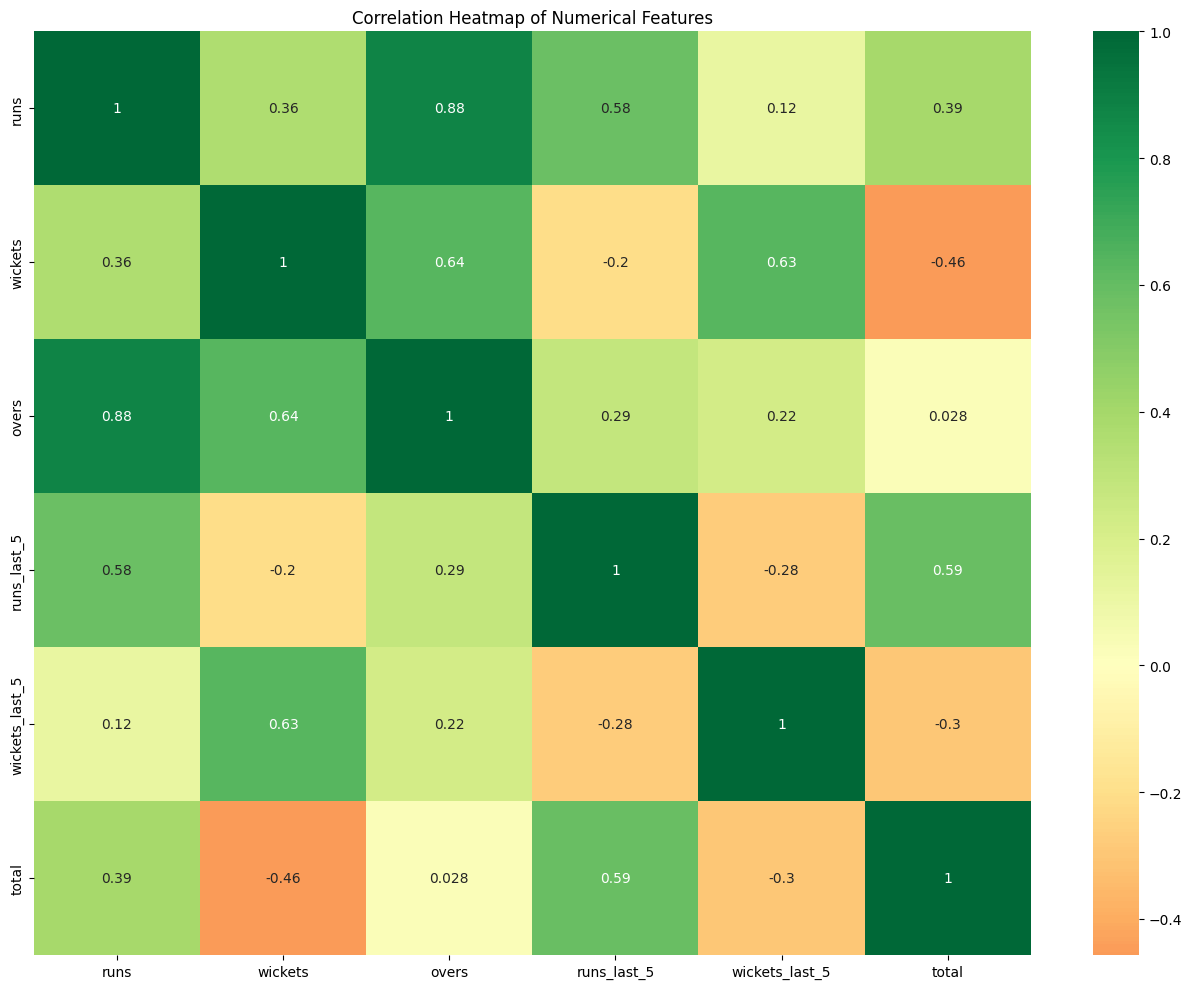

In [ ]:
# Selecting correlated features using Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Get only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=[np.number])

# Get correlation of all the numerical features of the dataset
corr_matrix = numerical_df.corr()
top_corr_features = corr_matrix.index

# Plotting the heatmapdo
plt.figure(figsize=(13,10))
g = sns.heatmap(data=numerical_df[top_corr_features].corr(), annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

# This cell creates a heatmap to visualize the correlation between numerical features in the dataset.
# It first selects only the numerical columns from the DataFrame df using select_dtypes(include=[np.number]).
# Then, it calculates the correlation matrix of these numerical features using the corr() method.
# The top_corr_features variable stores the column names of the features with the highest correlation.
# The heatmap is plotted using seaborn's heatmap function, with the correlation values annotated on the plot.
# The plot is titled 'Correlation Heatmap of Numerical Features' and displayed using plt.show().
# This heatmap helps identify which features are most strongly correlated with each other, which can be useful for feature selection and model building.

## **Data Preprocessing**
*• Handling categorical features*<br/>
*• Splitting dataset into train and test set on the basis of date*<br/>

In [ ]:
# Converting categorical features using OneHotEncoding method
encoded_df = pd.get_dummies(data=df, columns=['bat_team', 'bowl_team'])
encoded_df.columns

# This cell converts categorical features into numerical features using one-hot encoding.
# The pd.get_dummies() function is used to create dummy variables for the categorical features 'bat_team' and 'bowl_team'.
# The columns parameter specifies the categorical columns to be encoded.
# The result is a new DataFrame encoded_df with the dummy variables added.
# The columns attribute is used to display the column names of the encoded DataFrame.
# This transformation is useful for machine learning algorithms that require numerical input.

Index(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'total', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
       'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils',
       'bowl_team_Kings XI Punjab', 'bowl_team_Kolkata Knight Riders',
       'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
       'bowl_team_Royal Challengers Bangalore',
       'bowl_team_Sunrisers Hyderabad'],
      dtype='object')

In [ ]:
encoded_df.head()

# This cell displays the first 5 rows of the encoded DataFrame.
# The head() method is used to display the first few rows of the DataFrame.
# The output shows the first 5 rows of the encoded DataFrame, which contains the dummy variables for the categorical features 'bat_team' and 'bowl_team'.
# This transformation is useful for machine learning algorithms that require numerical input.

,date,runs,wickets,overs,runs_last_5,wickets_last_5,total,bat_team_Chennai Super Kings,bat_team_Delhi Daredevils,bat_team_Kings XI Punjab,...,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,bowl_team_Delhi Daredevils,bowl_team_Kings XI Punjab,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad
32,2008-04-18,61,0,5.1,59,0,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
33,2008-04-18,61,1,5.2,59,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
34,2008-04-18,61,1,5.3,59,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
35,2008-04-18,61,1,5.4,59,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False
36,2008-04-18,61,1,5.5,58,1,222,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Rearranging the columns
encoded_df = encoded_df[['date', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils', 'bat_team_Kings XI Punjab',
              'bat_team_Kolkata Knight Riders', 'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
              'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
              'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils', 'bowl_team_Kings XI Punjab',
              'bowl_team_Kolkata Knight Riders', 'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
              'bowl_team_Royal Challengers Bangalore', 'bowl_team_Sunrisers Hyderabad',
              'overs', 'runs', 'wickets', 'runs_last_5', 'wickets_last_5', 'total']]

# This cell rearranges the columns of the encoded DataFrame to place the categorical features 'bat_team' and 'bowl_team' at the beginning of the DataFrame.
# The columns are rearranged in the order specified in the list.
# The new DataFrame is assigned back to the variable encoded_df.
# The output shows the first few rows of the rearranged DataFrame, which contains the categorical features at the beginning and the numerical features at the end

In [ ]:
# Splitting the data into train and test set
X_train = encoded_df.drop(labels='total', axis=1)[encoded_df['date'].dt.year <= 2016]
X_test = encoded_df.drop(labels='total', axis=1)[encoded_df['date'].dt.year >= 2017]

y_train = encoded_df[encoded_df['date'].dt.year <= 2016]['total'].values
y_test = encoded_df[encoded_df['date'].dt.year >= 2017]['total'].values

# Removing the 'date' column
X_train.drop(labels='date', axis=True, inplace=True)
X_test.drop(labels='date', axis=True, inplace=True)

print("Training set: {} and Test set: {}".format(X_train.shape, X_test.shape))

# This cell splits the encoded DataFrame into training and test sets based on the year in the 'date' column.
# The training set contains data from 2016 and earlier, and the test set contains data from 2017 and later.
# The 'total' column is dropped from both sets to prepare for model training.
# The 'date' column is also dropped from both sets to remove it from the features.
# The shape of the training and test sets is printed to show the number of rows in each set.
# This cell splits the encoded DataFrame into training and test sets based on the year in the 'date' column.
# The training set contains data from 2016 and earlier, and the test set contains data from 2017 and later.
# The 'total' column is dropped from both sets to prepare for model training.
# The 'date' column is also dropped from both sets to remove it from the features.
# The shape of the training and test sets is printed to show the number of rows in each set.

Training set: (37330, 21) and Test set: (2778, 21)


## **Model Building**
I had done experiment with 4 different algorithms, they are as follows:<br/>
*• Linear Regression*<br/>
*• Decision Tree Regression*<br/>
*• Random Forest Regression*<br/>

----- Boosting Algorithm -----<br/>
*• Adaptive Boosting (AdaBoost) Algorithm*<br/>

### *Linear Regression*

In [ ]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
linear_regressor.fit(X_train,y_train)

# This cell fits a linear regression model to the training data.
# The LinearRegression() function creates a linear regression model object.
# The fit() method trains the model using the training data (X_train and y_train).
# The model is trained to predict the target variable 'total' based on the features in X_train.
# The trained model is stored in the variable linear_regressor.
# This cell fits a linear regression model to the training data.
# The LinearRegression() function creates a linear regression model object.
# The fit() method trains the model using the training data (X_train and y_train).
# The model is trained to predict the target variable 'total' based on the features in X_train.
# The trained model is stored in the variable linear_regressor.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Predicting results
y_pred_lr = linear_regressor.predict(X_test)

# This cell uses the trained linear regression model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_lr.
# This cell uses the trained linear regression model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_lr.

In [ ]:
# Linear Regression - Model Evaluation
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, accuracy_score
print("---- Linear Regression - Model Evaluation ----")
print("Mean Absolute Error (MAE): {}".format(mae(y_test, y_pred_lr)))
print("Mean Squared Error (MSE): {}".format(mse(y_test, y_pred_lr)))
print("Root Mean Squared Error (RMSE): {}".format(np.sqrt(mse(y_test, y_pred_lr))))

# This cell evaluates the performance of the linear regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.
# Root Mean Squared Error (RMSE): Measures the square root of the average squared difference between the predicted and actual values.
# The metrics are calculated using the y_test (actual values) and y_pred_lr (predicted values) arrays.
# The results are printed in a formatted manner.
# This cell evaluates the performance of the linear regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.

---- Linear Regression - Model Evaluation ----
Mean Absolute Error (MAE): 12.1186175461933
Mean Squared Error (MSE): 251.00792310417478
Root Mean Squared Error (RMSE): 15.843229566732118


### *Decision Tree*

In [ ]:
# Decision Tree Regression Model
from sklearn.tree import DecisionTreeRegressor
decision_regressor = DecisionTreeRegressor()
decision_regressor.fit(X_train,y_train)

# This cell fits a decision tree regression model to the training data.
# The DecisionTreeRegressor() function creates a decision tree regression model object.
# The fit() method trains the model using the training data (X_train and y_train).
# The model is trained to predict the target variable 'total' based on the features in X_train.
# The trained model is stored in the variable decision_regressor.
# This cell fits a decision tree regression model to the training data.
# The DecisionTreeRegressor() function creates a decision tree regression model object.
# The fit() method trains the model using the training data (X_train and y_train).
# The model is trained to predict the target variable 'total' based on the features in X_train.

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
# Predicting results
y_pred_dt = decision_regressor.predict(X_test)

# This cell uses the trained decision tree regression model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_dt.
# This cell uses the trained decision tree regression model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_dt.

In [ ]:
# Decision Tree Regression - Model Evaluation
print("---- Decision Tree Regression - Model Evaluation ----")
print("Mean Absolute Error (MAE): {}".format(mae(y_test, y_pred_dt)))
print("Mean Squared Error (MSE): {}".format(mse(y_test, y_pred_dt)))
print("Root Mean Squared Error (RMSE): {}".format(np.sqrt(mse(y_test, y_pred_dt))))

# This cell evaluates the performance of the decision tree regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.
# Root Mean Squared Error (RMSE): Measures the square root of the average squared difference between the predicted and actual values.
# The metrics are calculated using the y_test (actual values) and y_pred_dt (predicted values) arrays.
# The results are printed in a formatted manner.
# This cell evaluates the performance of the decision tree regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.

---- Decision Tree Regression - Model Evaluation ----
Mean Absolute Error (MAE): 17.10079193664507
Mean Squared Error (MSE): 532.8416126709864
Root Mean Squared Error (RMSE): 23.08336224796956


### *Random Forest*

In [ ]:
# Random Forest Regression Model
from sklearn.ensemble import RandomForestRegressor
random_regressor = RandomForestRegressor()
random_regressor.fit(X_train,y_train)

# This cell fits a random forest regression model to the training data.
# The RandomForestRegressor() function creates a random forest regression model object.
# The fit() method trains the model using the training data (X_train and y_train).
# The model is trained to predict the target variable 'total' based on the features in X_train.
# The trained model is stored in the variable random_regressor.
# This cell fits a random forest regression model to the training data.
# The RandomForestRegressor() function creates a random forest regression model object.
# The fit() method trains the model using the training data (X_train and y_train).
# The model is trained to predict the target variable 'total' based on the features in X_train.

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Predicting results
y_pred_rf = random_regressor.predict(X_test)

# This cell uses the trained random forest regression model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_rf.
# This cell uses the trained random forest regression model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_rf.

In [ ]:
# Random Forest Regression - Model Evaluation
print("---- Random Forest Regression - Model Evaluation ----")
print("Mean Absolute Error (MAE): {}".format(mae(y_test, y_pred_rf)))
print("Mean Squared Error (MSE): {}".format(mse(y_test, y_pred_rf)))
print("Root Mean Squared Error (RMSE): {}".format(np.sqrt(mse(y_test, y_pred_rf))))

# This cell evaluates the performance of the random forest regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.
# Root Mean Squared Error (RMSE): Measures the square root of the average squared difference between the predicted and actual values.
# The metrics are calculated using the y_test (actual values) and y_pred_rf (predicted values) arrays.
# The results are printed in a formatted manner.
# This cell evaluates the performance of the random forest regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.
# Root Mean Squared Error (RMSE): Measures the square root of the average squared difference between the predicted and actual values.

---- Random Forest Regression - Model Evaluation ----
Mean Absolute Error (MAE): 13.710281857451404
Mean Squared Error (MSE): 332.715603950444
Root Mean Squared Error (RMSE): 18.24049352266665


*Note: Since Linear Regression model performs best as compared to other two, we use this model and boost it's performance using AdaBoost Algorithm*

### *AdaBoost Algorithm*

In [ ]:
# AdaBoost Model using Linear Regression as the base learner
from sklearn.ensemble import AdaBoostRegressor
adb_regressor = AdaBoostRegressor(estimator=linear_regressor, n_estimators=100)
adb_regressor.fit(X_train, y_train)


# This cell fits an AdaBoost model using linear regression as the base learner.
# The AdaBoostRegressor() function creates an AdaBoost regression model object.
# The estimator parameter specifies the base learner to be used, which is the linear regression model.
# The n_estimators parameter specifies the number of weak learners to be used, which is 100 in this case.
# The fit() method trains the model using the training data (X_train and y_train).
# The model is trained to predict the target variable 'total' based on the features in X_train.
# The trained model is stored in the variable adb_regressor.
# This cell fits an AdaBoost model using linear regression as the base learner.
# The AdaBoostRegressor() function creates an AdaBoost regression model object.

,estimator,LinearRegression()
,n_estimators,100
,learning_rate,1.0
,loss,'linear'
,random_state,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Predicting results
y_pred_adb = adb_regressor.predict(X_test)

# This cell uses the trained AdaBoost model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_adb.
# This cell uses the trained AdaBoost model to make predictions on the test data (X_test).
# The predict() method is used to generate predictions based on the test data.
# The predictions are stored in the variable y_pred_adb.

In [ ]:
# AdaBoost Regression - Model Evaluation
print("---- AdaBoost Regression - Model Evaluation ----")
print("Mean Absolute Error (MAE): {}".format(mae(y_test, y_pred_adb)))
print("Mean Squared Error (MSE): {}".format(mse(y_test, y_pred_adb)))
print("Root Mean Squared Error (RMSE): {}".format(np.sqrt(mse(y_test, y_pred_adb))))

# This cell evaluates the performance of the AdaBoost regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.
# Root Mean Squared Error (RMSE): Measures the square root of the average squared difference between the predicted and actual values.
# The metrics are calculated using the y_test (actual values) and y_pred_adb (predicted values) arrays.
# The results are printed in a formatted manner.
# This cell evaluates the performance of the AdaBoost regression model using three different metrics:
# Mean Absolute Error (MAE): Measures the average absolute difference between the predicted and actual values.
# Mean Squared Error (MSE): Measures the average squared difference between the predicted and actual values.    

---- AdaBoost Regression - Model Evaluation ----
Mean Absolute Error (MAE): 12.090694322340065
Mean Squared Error (MSE): 246.31631394414345
Root Mean Squared Error (RMSE): 15.694467622195518


*Note: Using AdaBoost did not reduce the error to a significant level. Hence, we will you simple linear regression model for prediction*

## **Predictions**
• Model *trained on* the data from **IPL Seasons 1 to 9** ie: (2008 to 2016)<br/>
• Model *tested on* data from **IPL Season 10** ie: (2017)<br/>
• Model *predicts on* data from **IPL Seasons 11 to 12** ie: (2018 to 2019)

In [ ]:
def predict_score(batting_team='Chennai Super Kings', bowling_team='Mumbai Indians', overs=5.1, runs=50, wickets=0, runs_in_prev_5=50, wickets_in_prev_5=0):
  temp_array = list()

  # Batting Team
  if batting_team == 'Chennai Super Kings':
    temp_array = temp_array + [1,0,0,0,0,0,0,0]
  elif batting_team == 'Delhi Daredevils':
    temp_array = temp_array + [0,1,0,0,0,0,0,0]
  elif batting_team == 'Kings XI Punjab':
    temp_array = temp_array + [0,0,1,0,0,0,0,0]
  elif batting_team == 'Kolkata Knight Riders':
    temp_array = temp_array + [0,0,0,1,0,0,0,0]
  elif batting_team == 'Mumbai Indians':
    temp_array = temp_array + [0,0,0,0,1,0,0,0]
  elif batting_team == 'Rajasthan Royals':
    temp_array = temp_array + [0,0,0,0,0,1,0,0]
  elif batting_team == 'Royal Challengers Bangalore':
    temp_array = temp_array + [0,0,0,0,0,0,1,0]
  elif batting_team == 'Sunrisers Hyderabad':
    temp_array = temp_array + [0,0,0,0,0,0,0,1]

  # Bowling Team
  if bowling_team == 'Chennai Super Kings':
    temp_array = temp_array + [1,0,0,0,0,0,0,0]
  elif bowling_team == 'Delhi Daredevils':
    temp_array = temp_array + [0,1,0,0,0,0,0,0]
  elif bowling_team == 'Kings XI Punjab':
    temp_array = temp_array + [0,0,1,0,0,0,0,0]
  elif bowling_team == 'Kolkata Knight Riders':
    temp_array = temp_array + [0,0,0,1,0,0,0,0]
  elif bowling_team == 'Mumbai Indians':
    temp_array = temp_array + [0,0,0,0,1,0,0,0]
  elif bowling_team == 'Rajasthan Royals':
    temp_array = temp_array + [0,0,0,0,0,1,0,0]
  elif bowling_team == 'Royal Challengers Bangalore':
    temp_array = temp_array + [0,0,0,0,0,0,1,0]
  elif bowling_team == 'Sunrisers Hyderabad':
    temp_array = temp_array + [0,0,0,0,0,0,0,1]

  # Overs, Runs, Wickets, Runs_in_prev_5, Wickets_in_prev_5
  temp_array = temp_array + [overs, runs, wickets, runs_in_prev_5, wickets_in_prev_5]

  # Converting into numpy array
  temp_array = np.array([temp_array])

  # Prediction
  return int(linear_regressor.predict(temp_array)[0])
  # return int(adb_regressor.predict(temp_array)[0])  # For AdaBoost
  # return int(decision_regressor.predict(temp_array)[0])  # For Decision Tree
  # return int(random_regressor.predict(temp_array)[0])  # For Random Forest
  
  # Defines a function called predict_score with default parameters for all inputs.
  # This function creates a user-friendly interface for making score predictions 
  # by taking human-readable inputs and converting them to the format expected by the trained model.
  # temp_array = list() - Initializes an empty list to store the feature values
  #  Batting team encoding Converts the batting team name to one-hot encoded format (8 binary values)
  # 13-20: Bowling team encoding Converts the bowling team name to one-hot encoded format (8 binary values)
  # 21-22: temp_array = temp_array + [overs, runs, wickets, runs_in_prev_5, wickets_in_prev_5] Adds the numerical features to the array 
  # 25: Converting into numpy array
  # 28: Makes a prediction using the trained linear regression model and returns the result as an integer
  # 29: Returning the predicted score as an integer
  # 30: For AdaBoost
  # 31: For Decision Tree
  # 32: For Random Forest


### **Prediction 1**
• Date: 16th April 2018<br/>
• IPL : Season 11<br/>
• Match number: 13<br/>
• Teams: Kolkata Knight Riders vs. Delhi Daredevils<br/>
• First Innings final score: 200/9


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
final_score = predict_score(batting_team='Kolkata Knight Riders', bowling_team='Delhi Daredevils', overs=9.2, runs=79, wickets=2, runs_in_prev_5=60, wickets_in_prev_5=1)
print("The final predicted score (range): {} to {}".format(final_score-10, final_score+5))

# This cell makes a prediction for a match between Kolkata Knight Riders and Delhi Daredevils, 
# with 9.2 overs bowled, 79 runs scored, 2 wickets taken, 60 runs in the previous 5 overs, 
# and 1 wicket in the previous 5 overs. The prediction is then printed in a formatted manner, 
# showing a range of possible scores.  

The final predicted score (range): 159 to 174


### **Prediction 2**
• Date: 7th May 2018<br/>
• IPL : Season 11<br/>
• Match number: 39<br/>
• Teams: Sunrisers Hyderabad vs. Royal Challengers Bangalore<br/>
• First Innings final score: 146/10


In [125]:
final_score = predict_score(batting_team='Sunrisers Hyderabad', bowling_team='Royal Challengers Bangalore', overs=10.5, runs=67, wickets=3, runs_in_prev_5=29, wickets_in_prev_5=1)
print("The final predicted score (range): {} to {}".format(final_score-10, final_score+5))

The final predicted score (range): 138 to 153


### **Prediction 3**
• Date: 17th May 2018<br/>
• IPL : Season 11<br/>
• Match number: 50<br/>
• Teams: Mumbai Indians vs. Kings XI Punjab<br/>
• First Innings final score: 186/8<br/>


In [126]:
final_score = predict_score(batting_team='Mumbai Indians', bowling_team='Kings XI Punjab', overs=14.1, runs=136, wickets=4, runs_in_prev_5=50, wickets_in_prev_5=0)
print("The final predicted score (range): {} to {}".format(final_score-10, final_score+5))

The final predicted score (range): 180 to 195


### **Prediction 4**
• Date: 30th March 2019<br/>
• IPL : Season 12<br/>
• Match number: 9<br/>
• Teams: Mumbai Indians vs. Kings XI Punjab<br/>
• First Innings final score: 176/7


In [127]:
final_score = predict_score(batting_team='Mumbai Indians', bowling_team='Kings XI Punjab', overs=12.3, runs=113, wickets=2, runs_in_prev_5=55, wickets_in_prev_5=0)
print("The final predicted score (range): {} to {}".format(final_score-10, final_score+5))

The final predicted score (range): 179 to 194


### **Prediction 5**
• Date: 11th April 2019<br/>
• IPL : Season 12<br/>
• Match number: 25<br/>
• Teams: Rajasthan Royals vs. Chennai Super Kings<br/>
• First Innings final score: 151/7


In [128]:
final_score = predict_score(batting_team='Rajasthan Royals', bowling_team='Chennai Super Kings', overs=13.3, runs=92, wickets=5, runs_in_prev_5=27, wickets_in_prev_5=2)
print("The final predicted score (range): {} to {}".format(final_score-10, final_score+5))

The final predicted score (range): 128 to 143


### **Prediction 6**
• Date: 14th April 2019<br/>
• IPL : Season 12<br/>
• Match number: 30<br/>
• Teams: Sunrisers Hyderabad vs. Delhi Daredevils<br/>
• First Innings final score: 155/7


In [129]:
final_score = predict_score(batting_team='Delhi Daredevils', bowling_team='Sunrisers Hyderabad', overs=11.5, runs=98, wickets=3, runs_in_prev_5=41, wickets_in_prev_5=1)
print("The final predicted score (range): {} to {}".format(final_score-10, final_score+5))

The final predicted score (range): 157 to 172


### **Prediction 7**
• Date: 10th May 2019<br/>
• IPL : Season 12<br/>
• Match number: 59 (Eliminator)<br/>
• Teams: Delhi Daredevils vs. Chennai Super Kings<br/>
• First Innings final score: 147/9


In [130]:
final_score = predict_score(batting_team='Delhi Daredevils', bowling_team='Chennai Super Kings', overs=10.2, runs=68, wickets=3, runs_in_prev_5=29, wickets_in_prev_5=1)
print("The final predicted score (range): {} to {}".format(final_score-10, final_score+5))

The final predicted score (range): 137 to 152


*Note: In IPL, it is very difficult to predict the actual score because in a moment of time the game can completely turn upside down!*
